# 1.1 Feature Extraction – Schritt für Schritt

Dieses Notebook zeigt wie Feature Extraction funktioniert.
Wir gehen jeden Schritt einzeln durch und visualisieren das Ergebnis.

**Pipeline:**
```
Originalbild
    → Schritt 1: Graustufen
    → Schritt 2: Gauss-Filter (Rauschen entfernen)
    → Schritt 3: Keypoint-Erkennung (FAST)
    → Schritt 4: Descriptor berechnen (ORB)
    → Schritt 5: Schwache Features filtern
```

Gefundene Bilder: 275
Erstes Bild: 1614256757008110848.png


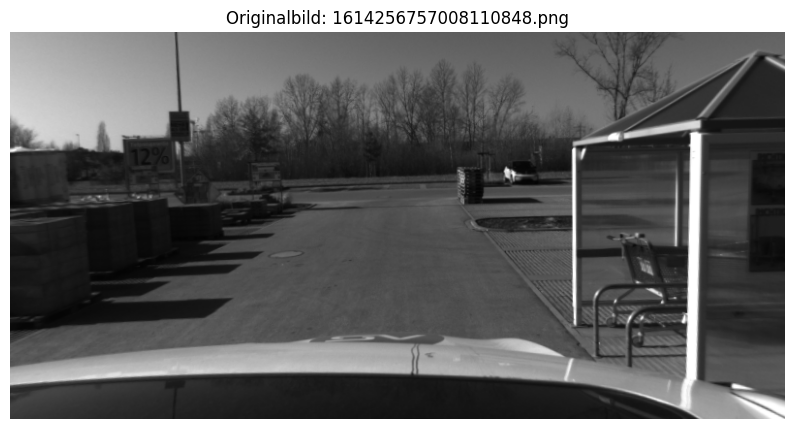

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Ordner mit cam0 Bildern
CAM0_ORDNER = "../cam0"

# Erstes verfügbares Bild laden
bilder = sorted(os.listdir(CAM0_ORDNER))
print(f"Gefundene Bilder: {len(bilder)}")
print(f"Erstes Bild: {bilder[0]}")

bildpfad = os.path.join(CAM0_ORDNER, bilder[0])
original = cv2.imread(bildpfad)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(original_rgb)
plt.title(f"Originalbild: {bilder[0]}")
plt.axis('off')
plt.show()

---
## Schritt 1: Graustufen

Feature Extraction arbeitet auf Graustufen-Bildern — Farbe ist irrelevant.
Wir brauchen nur **Helligkeitsunterschiede** um Ecken und Kanten zu finden.

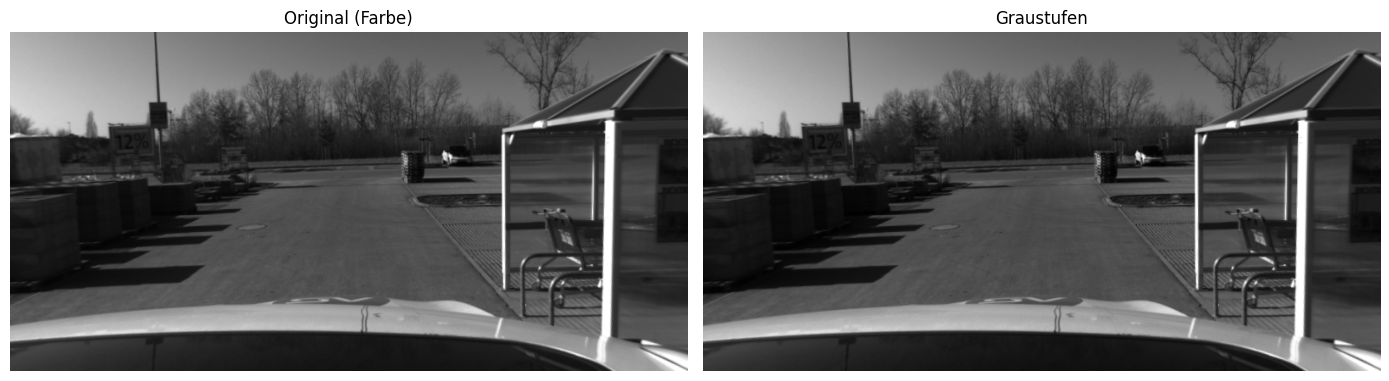

Bildgröße: 800 x 400 Pixel


In [2]:
grau = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(original_rgb)
axes[0].set_title("Original (Farbe)")
axes[0].axis('off')

axes[1].imshow(grau, cmap='gray')
axes[1].set_title("Graustufen")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Bildgröße: {grau.shape[1]} x {grau.shape[0]} Pixel")

---
## Schritt 2: Gauss-Filter

Das Bild wird leicht weichgezeichnet um **Rauschen zu entfernen**.
Ohne diesen Schritt würde der Algorithmus einzelne verrauschte Pixel fälschlicherweise als Features erkennen.

```
Ohne Filter:  120 | 145 | 118 | 122  ← Rauschen
Mit Filter:   121 | 126 | 120 | 121  ← geglättet
```

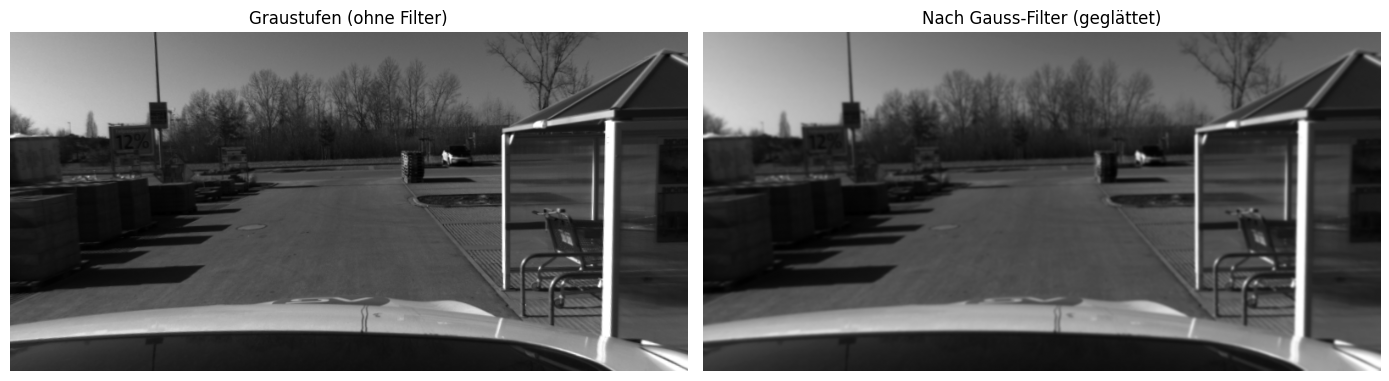

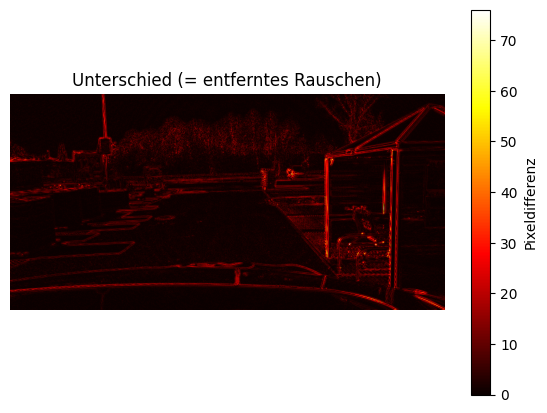

In [3]:
# Gauss-Filter anwenden (5x5 Kernel)
geglättet = cv2.GaussianBlur(grau, (5, 5), 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(grau, cmap='gray')
axes[0].set_title("Graustufen (ohne Filter)")
axes[0].axis('off')

axes[1].imshow(geglättet, cmap='gray')
axes[1].set_title("Nach Gauss-Filter (geglättet)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Unterschied sichtbar machen
differenz = cv2.absdiff(grau, geglättet)
plt.figure(figsize=(7, 5))
plt.imshow(differenz, cmap='hot')
plt.title("Unterschied (= entferntes Rauschen)")
plt.colorbar(label='Pixeldifferenz')
plt.axis('off')
plt.show()

---
## Schritt 3: Keypoint-Erkennung (FAST)

Der FAST-Algorithmus sucht nach **Ecken** im Bild.
Für jeden Pixel wird ein Kreis von 16 Nachbarn geprüft:

```
→ Sind 12 von 16 Nachbarn deutlich heller oder dunkler?
→ JA  → Ecke gefunden (Keypoint)
→ NEIN → kein Keypoint
```

Der **Schwellwert** bestimmt wie sensibel die Erkennung ist.

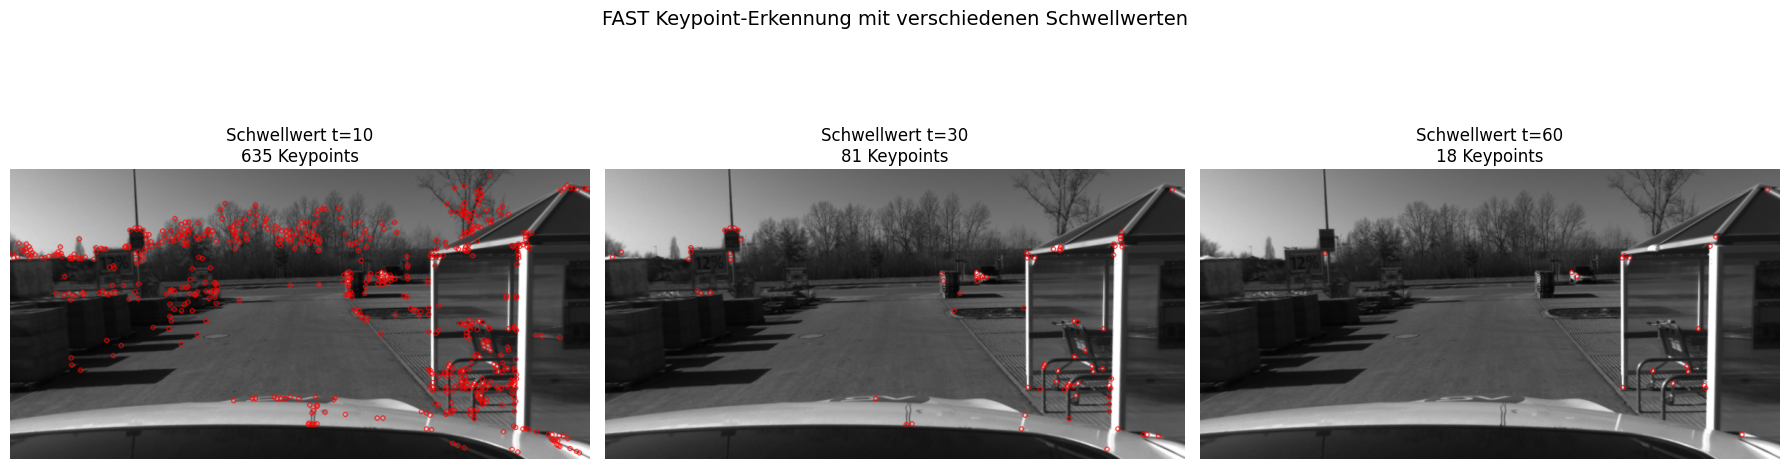

Je kleiner der Schwellwert → mehr (aber schwächere) Features
Je größer der Schwellwert → weniger (aber stärkere) Features


In [4]:
# FAST mit verschiedenen Schwellwerten vergleichen
schwellwerte = [10, 30, 60]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, t in enumerate(schwellwerte):
    fast = cv2.FastFeatureDetector_create(threshold=t, nonmaxSuppression=True)
    keypoints = fast.detect(geglättet, None)
    
    bild_kp = cv2.drawKeypoints(original_rgb, keypoints, None, color=(255, 0, 0))
    
    axes[i].imshow(bild_kp)
    axes[i].set_title(f"Schwellwert t={t}\n{len(keypoints)} Keypoints")
    axes[i].axis('off')

plt.suptitle("FAST Keypoint-Erkennung mit verschiedenen Schwellwerten", fontsize=14)
plt.tight_layout()
plt.show()

print("Je kleiner der Schwellwert → mehr (aber schwächere) Features")
print("Je größer der Schwellwert → weniger (aber stärkere) Features")

---
## Schritt 4: Descriptor berechnen (ORB)

Jeder Keypoint bekommt einen **Fingerabdruck** (Descriptor).
Der ORB-Descriptor ist ein 256-bit Binärcode:

```
Für 256 zufällige Pixelpaare (a, b) um den Keypoint:
  Helligkeit(a) > Helligkeit(b) → 1
  Helligkeit(a) < Helligkeit(b) → 0

→ Ergebnis: z.B. 10110101001110...
```

Dieser Code ermöglicht es, denselben Punkt im nächsten Frame **wiederzufinden**.

Anzahl gefundener Keypoints: 500
Descriptor-Form: (500, 32)  ← (500 Punkte × 32 Bytes = 256 bits)

Beispiel Descriptor des 1. Keypoints (als Binär):
10110100 00000100 01101110 11011101 ...


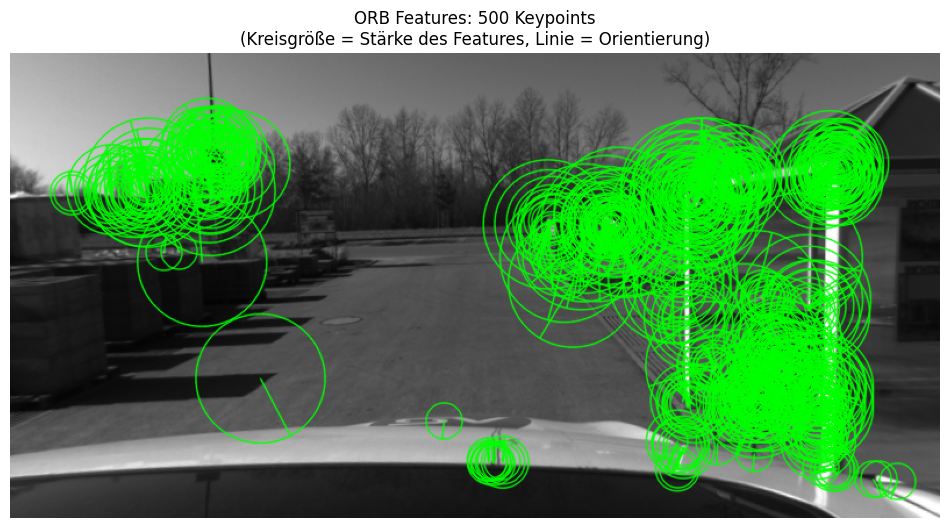

In [5]:
# ORB: erkennt Keypoints UND berechnet Descriptors
orb = cv2.ORB_create(nfeatures=500)
keypoints, descriptors = orb.detectAndCompute(geglättet, None)

print(f"Anzahl gefundener Keypoints: {len(keypoints)}")
print(f"Descriptor-Form: {descriptors.shape}  ← ({len(keypoints)} Punkte × 32 Bytes = 256 bits)")
print(f"\nBeispiel Descriptor des 1. Keypoints (als Binär):")
print(' '.join(format(b, '08b') for b in descriptors[0][:4]), "...")

# Visualisierung
bild_orb = cv2.drawKeypoints(original_rgb, keypoints, None,
                              color=(0, 255, 0),
                              flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

plt.figure(figsize=(12, 7))
plt.imshow(bild_orb)
plt.title(f"ORB Features: {len(keypoints)} Keypoints\n(Kreisgröße = Stärke des Features, Linie = Orientierung)")
plt.axis('off')
plt.show()

---
## Schritt 5: Wo werden Features gefunden?

Nicht alle Bildbereiche liefern gleich viele Features.
Wir visualisieren die **Verteilung** der Keypoints über das Bild.

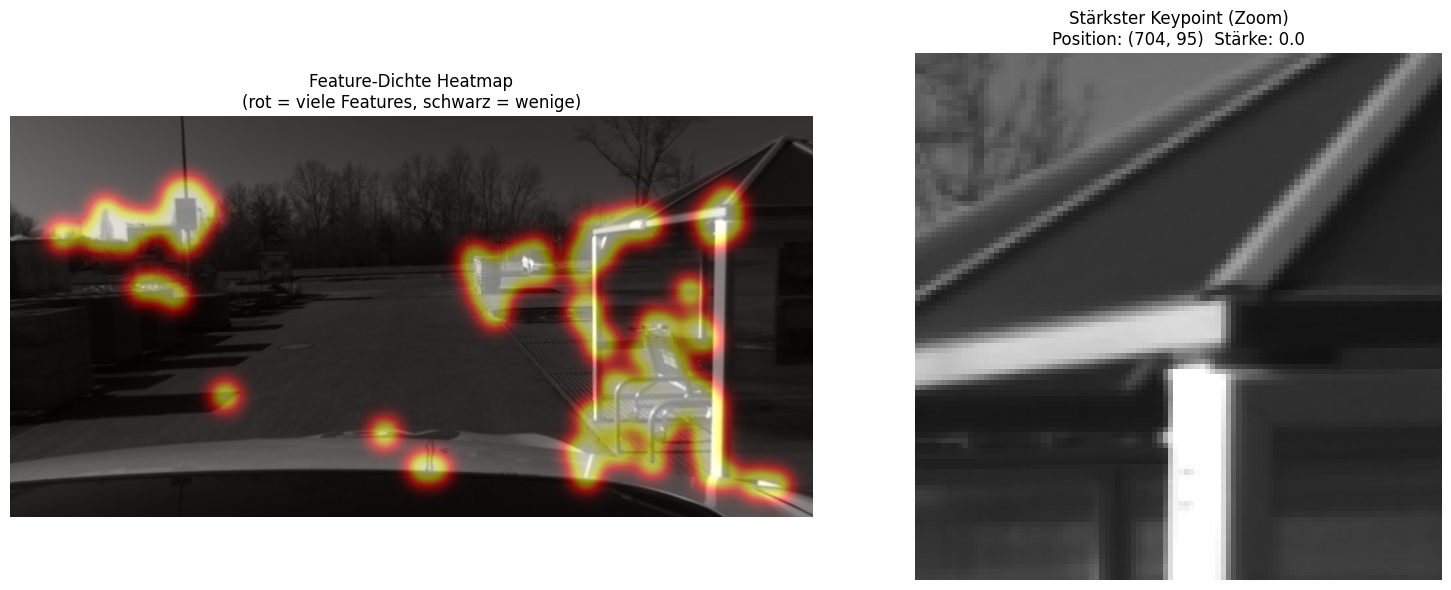

In [6]:
# Heatmap der Feature-Dichte
heatmap = np.zeros(grau.shape, dtype=np.float32)

for kp in keypoints:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    cv2.circle(heatmap, (x, y), 15, 1, -1)

heatmap = cv2.GaussianBlur(heatmap, (51, 51), 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(original_rgb)
axes[0].imshow(heatmap, cmap='hot', alpha=0.5)
axes[0].set_title("Feature-Dichte Heatmap\n(rot = viele Features, schwarz = wenige)")
axes[0].axis('off')

# Zoom auf interessante Region
stärkster_kp = max(keypoints, key=lambda kp: kp.response)
x, y = int(stärkster_kp.pt[0]), int(stärkster_kp.pt[1])
rand = 50
ausschnitt = original_rgb[max(0,y-rand):y+rand, max(0,x-rand):x+rand]

axes[1].imshow(ausschnitt)
axes[1].set_title(f"Stärkster Keypoint (Zoom)\nPosition: ({x}, {y})  Stärke: {stärkster_kp.response:.1f}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## Zusammenfassung

```
Schritt 1: Graustufen      → Farbe irrelevant, nur Helligkeit zählt
Schritt 2: Gauss-Filter    → Rauschen entfernen
Schritt 3: FAST            → WO sind die Features? (x, y)
Schritt 4: ORB Descriptor  → WIE sehen sie aus? (256-bit Fingerabdruck)
Schritt 5: Filter          → nur die stärksten N Features behalten
```

**Output:** Eine Liste von Punkten mit Position + Descriptor → bereit für Feature Matching in 1.2

In [7]:
# Finales Ergebnis
print("=" * 50)
print("FEATURE EXTRACTION – ERGEBNIS")
print("=" * 50)
print(f"Input:       {bilder[0]}  ({grau.shape[1]}x{grau.shape[0]} px)")
print(f"Keypoints:   {len(keypoints)}")
print(f"Descriptors: {descriptors.shape[0]} × {descriptors.shape[1]*8} bit")
print()
print("Top 5 stärkste Features:")
top5 = sorted(keypoints, key=lambda kp: kp.response, reverse=True)[:5]
for i, kp in enumerate(top5):
    print(f"  {i+1}. Position: ({int(kp.pt[0])}, {int(kp.pt[1])})  Stärke: {kp.response:.1f}")

FEATURE EXTRACTION – ERGEBNIS
Input:       1614256757008110848.png  (800x400 px)
Keypoints:   500
Descriptors: 500 × 256 bit

Top 5 stärkste Features:
  1. Position: (704, 95)  Stärke: 0.0
  2. Position: (695, 104)  Stärke: 0.0
  3. Position: (706, 105)  Stärke: 0.0
  4. Position: (707, 107)  Stärke: 0.0
  5. Position: (699, 104)  Stärke: 0.0


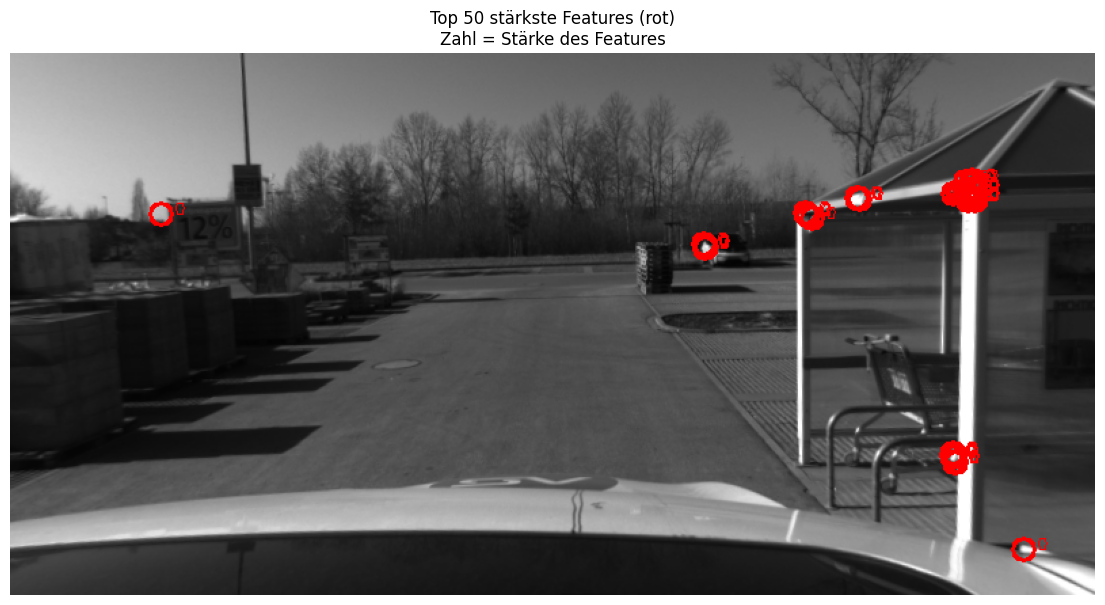

Top 10 stärkste Features:
   1. Position: ( 704,   95)   Stärke: 0.0
   2. Position: ( 695,  104)   Stärke: 0.0
   3. Position: ( 706,  105)   Stärke: 0.0
   4. Position: ( 707,  107)   Stärke: 0.0
   5. Position: ( 699,  104)   Stärke: 0.0
   6. Position: ( 706,  109)   Stärke: 0.0
   7. Position: ( 698,  103)   Stärke: 0.0
   8. Position: ( 512,  142)   Stärke: 0.0
   9. Position: ( 699,  103)   Stärke: 0.0
  10. Position: ( 512,  142)   Stärke: 0.0


In [8]:
# Nur die Top 50 stärksten Features anzeigen
top50 = sorted(keypoints, key=lambda kp: kp.response, reverse=True)[:50]

bild_top = original_rgb.copy()
for kp in top50:
    x, y = int(kp.pt[0]), int(kp.pt[1])
    staerke = int(kp.response)
    # Kreis um den Punkt
    cv2.circle(bild_top, (x, y), 8, (255, 0, 0), 2)
    # Stärke als Zahl daneben
    cv2.putText(bild_top, str(staerke), (x+10, y), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)

plt.figure(figsize=(14, 8))
plt.imshow(bild_top)
plt.title("Top 50 stärkste Features (rot)\nZahl = Stärke des Features")
plt.axis('off')
plt.show()

print("Top 10 stärkste Features:")
for i, kp in enumerate(top50[:10]):
    print(f"  {i+1:2}. Position: ({int(kp.pt[0]):4}, {int(kp.pt[1]):4})   Stärke: {kp.response:.1f}")